In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/transactions_clean.csv")

df["transaction_date"] = pd.to_datetime(df["transaction_date"])

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (14950, 10)


,transaction_id,customer_id,transaction_date,amount,currency,country,transaction_type,status,transaction_month,is_successful
0,1,2620,2025-02-27 00:47:00,553.68,EUR,France,Card Payment,Failed,2025-02,0
1,2,357,2025-10-30 13:02:00,64.45,EUR,France,Card Payment,Failed,2025-10,0
2,3,815,2025-11-29 22:34:00,841.94,USD,Germany,Cash Withdrawal,Completed,2025-11,1
3,4,654,2025-12-24 13:21:00,559.35,GBP,France,Card Payment,Completed,2025-12,1
4,5,1557,2025-02-19 11:54:00,691.19,EUR,United Kingdom,Online Payment,Failed,2025-02,0


In [25]:
summary = df[["amount"]].describe()

summary

,amount
count,14950.000000
mean,1001.837017
std,576.601049
min,5.010000
25%,500.380000
50%,1004.545000
75%,1504.185000
max,1999.950000


In [26]:
country_analysis = (
    df.groupby("country")
    .agg(
        transactions=("transaction_id", "count"),
        total_amount=("amount", "sum"),
        average_amount=("amount", "mean"),
        successful_transactions=("is_successful", "sum")
    )
)

country_analysis["success_rate"] = (
    country_analysis["successful_transactions"]
    / country_analysis["transactions"]
    * 100
).round(2)

country_analysis.sort_values(
    "total_amount",
    ascending=False
)

,transactions,total_amount,average_amount,successful_transactions,success_rate
country,,,,,
Germany,2533,2531518.85,999.415259,1521,60.05
Spain,2480,2509203.42,1011.775573,1509,60.85
United Kingdom,2468,2494105.69,1010.577670,1473,59.68
Portugal,2464,2467727.62,1001.512833,1528,62.01
France,2431,2445983.26,1006.163414,1445,59.44
Senegal,2424,2390781.70,986.296081,1423,58.70
Unknown,150,138142.87,920.952467,81,54.00


In [29]:
monthly_analysis = (
    df.groupby("transaction_month")
    .agg(
        transactions=("transaction_id", "count"),
        total_amount=("amount", "sum"),
        successful_transactions=("is_successful", "sum")
    )
)

monthly_analysis["success_rate"] = (
    monthly_analysis["successful_transactions"]
    / monthly_analysis["transactions"]
    * 100
).round(2)

monthly_analysis

,transactions,total_amount,successful_transactions,success_rate
transaction_month,,,,
2025-01,1221,1227385.18,705,57.74
2025-02,1164,1203156.61,683,58.68
2025-03,1273,1285440.95,765,60.09
2025-04,1220,1221696.60,774,63.44
2025-05,1239,1246806.32,735,59.32
2025-06,1210,1199240.49,724,59.83
2025-07,1238,1224158.42,758,61.23
2025-08,1252,1263866.27,744,59.42
2025-09,1263,1231842.04,759,60.10


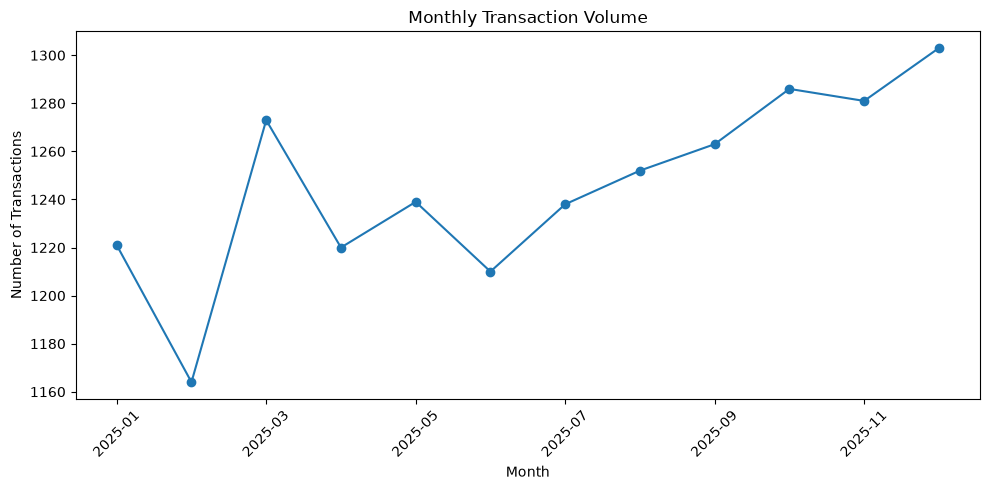

In [31]:
monthly_analysis["transactions"].plot(
    kind="line",
    figsize=(10, 5),
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

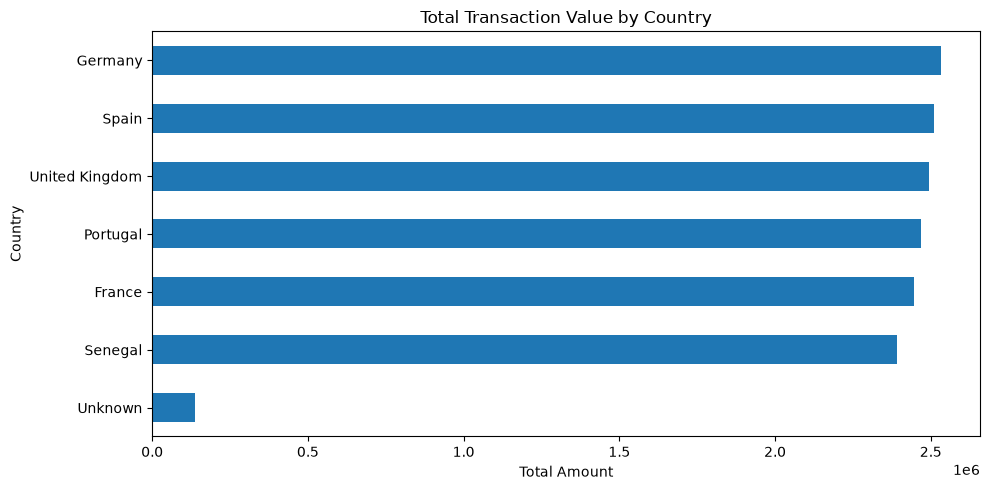

In [ ]:
country_analysis["total_amount"].sort_values().plot(
    kind="barh",
    figsize=(10, 5)
)

plt.title("Total Transaction Value by Country")
plt.xlabel("Total Amount")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## ETL Pipeline Architecture

The pipeline follows a reproducible Extract, Transform, Validate, and Load workflow.

Raw transaction data is extracted from the raw CSV dataset, transformed through cleaning and normalization steps, validated using automated data quality checks, and loaded into a processed dataset for analytical use.

### Pipeline

Raw CSV
→ Extract
→ Transform
→ Validate
→ Processed CSV
→ SQL Analytics
→ Business Insights